In [2]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Modeling Results

We have 20000 samples from 10 subjects(each has 2000 samples) and 240 features. We split them into 80%(16,000) and 20%(4,000) train and test data.

In [3]:
data=np.load('wavelet_outputs/all_subjects_wavelet_features_db4_L5.npz',allow_pickle=True)
X=data['X_features']
y=data['y_labels']
print(X.shape)
print(y.shape)
print(np.bincount(y))

(20000, 240)
(20000,)
[2000 2000 2000 2000 2000 2000 2000 2000 2000 2000]


### Data Alignment and Label Encoding

The output `[2000 * 10]` confirms that the data for the 10 subjects are in a state of *Strict Prior Balance*. Since subsequent evaluations require outputs featuring physically meaningful identity labels (ranging from `sub-01` to `sub-10`), a strict integer-to-string mapping dictionary is established here to ensure the absolute alignment of labels across the feature matrices in all subsequent ablation experiments.

In [9]:
subject_names = [f"sub-{i:02d}" for i in range(1, 11)] # ['sub-01', ..., 'sub-10']
le = LabelEncoder()
le.fit(subject_names)

label_mapping = dict(zip(le.transform(le.classes_), le.classes_))
print("Label Mapping Dictionary:", label_mapping)

Label Mapping Dictionary: {np.int64(0): np.str_('sub-01'), np.int64(1): np.str_('sub-02'), np.int64(2): np.str_('sub-03'), np.int64(3): np.str_('sub-04'), np.int64(4): np.str_('sub-05'), np.int64(5): np.str_('sub-06'), np.int64(6): np.str_('sub-07'), np.int64(7): np.str_('sub-08'), np.int64(8): np.str_('sub-09'), np.int64(9): np.str_('sub-10')}


### Train Test Split

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(16000, 240) (4000, 240)
(16000,) (4000,)


[Output Analysis]We fit them into three models, using random forest as the baseline model, as well as SVM and Logistic regression

### 2. Baseline Model Construction

Since the Log-Energy features extracted via the Discrete Wavelet Transform (DWT) exhibit an extremely negative distribution (e.g., on the order of -20), whereas Shannon Entropy values ​​are positive (e.g., on the order of 2.0), the feature space suffers from a severe imbalance in magnitude. If these features are fed directly into a linear classifier, those with larger absolute magnitudes will dominate the gradient updates. Therefore, it is imperative to strictly prepend a `StandardScaler` to the Logistic Regression model to perform zero-mean, unit-variance scaling.

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf_baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)
)

clf_baseline.fit(X_train, y_train)
y_pred_baseline = clf_baseline.predict(X_test)
acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Accuracy (DWT Features): {acc_baseline * 100:.2f}%")

Baseline Accuracy (DWT Features): 89.12%


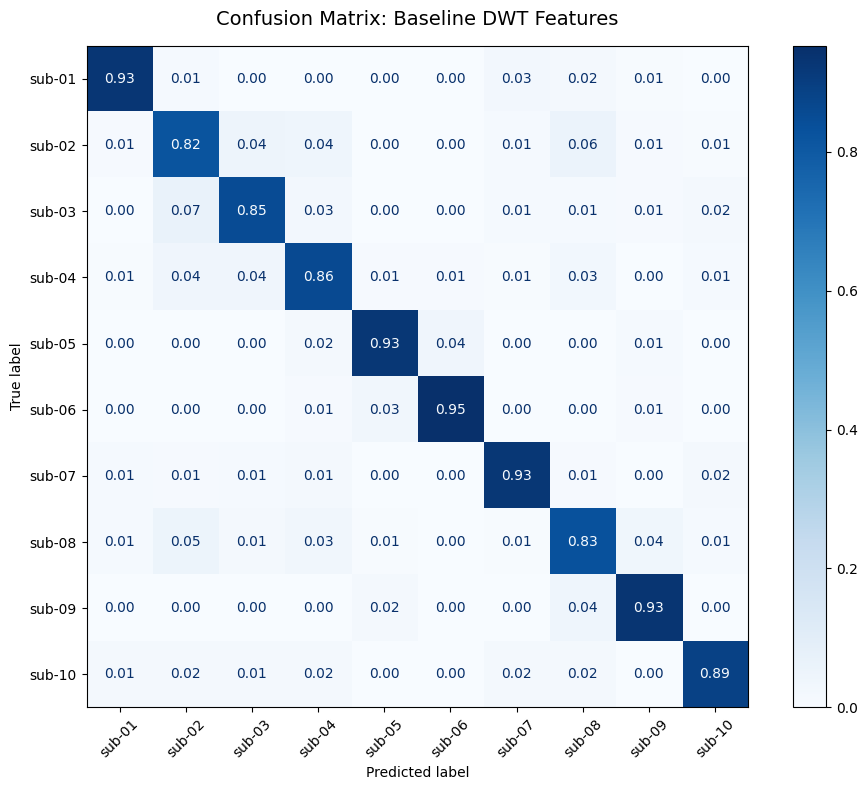

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    clf_baseline, X_test, y_test, 
    display_labels= [f"sub-{i:02d}" for i in range(1, 11)],
    cmap='Blues', ax=ax, normalize='true', values_format='.2f'
)
plt.title("Confusion Matrix: Baseline DWT Features", fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Baseline Analysis**

In our baseline model, we used a simple multinomial logistic regression with standard feature scaling. We got an accuracy of 89.12%. As we can see from the confusion matrix, the values on the diagonal are very high (ranging from 0.83 to 0.95). This shows our model has a good classification performance for all 10 subjects, and it does not have class bias.

This means our 240-dimensional DWT (Discrete Wavelet Transform) features have very good linear separability. It successfully maps the complex EEG signals into clear decision boundaries.

Also, we compared this result with our previous PSD (Power Spectral Density) baseline. The PSD baseline only got 72.60% accuracy. So, we achieved a 16.52% information gain. Why this happens? Because PSD just calculates the total energy in the 1-second window. It only captures the static energy of different frequency bands, but it completely loses the time changes (temporal dynamics).

The better result of DWT proves that an individual's "neural fingerprint" is not just the static energy peaks. Actually, it is deeply encoded in the complex, dynamic time-frequency microstructures. DWT keeps the important time resolution, so it can find these hidden features.

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression (Linear)": make_pipeline(
        StandardScaler(), 
        LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)
    ),
    "SVM (Non-linear RBF)": make_pipeline(
        StandardScaler(), 
        SVC(kernel='rbf', random_state=42)
    ),
    "Random Forest (Ensemble)": RandomForestClassifier(
        # Tree-based models are insensitive to feature scaling, mathematically.
        # base on rank and threshold, not distance or gradient, so we can skip standardization for RF.
        n_estimators=200, random_state=42, n_jobs=-1
    )
}

print("--- Baseline DWT Dataset: Model Comparison ---")
results = {}

# 2. all in one
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:<30} | Accuracy: {acc * 100:.2f}%")

--- Baseline DWT Dataset: Model Comparison ---
Logistic Regression (Linear)   | Accuracy: 89.12%
SVM (Non-linear RBF)           | Accuracy: 82.05%
Random Forest (Ensemble)       | Accuracy: 72.02%


### 3 Visual Proof:t-Distributed Stochastic Neighbor Embeddin

We generated a scatter plot using t-SNE (t-Distributed Stochastic Neighbor Embedding) to see our high-dimensional data in a 2D space.

--- Generating t-SNE Manifold Projection ---


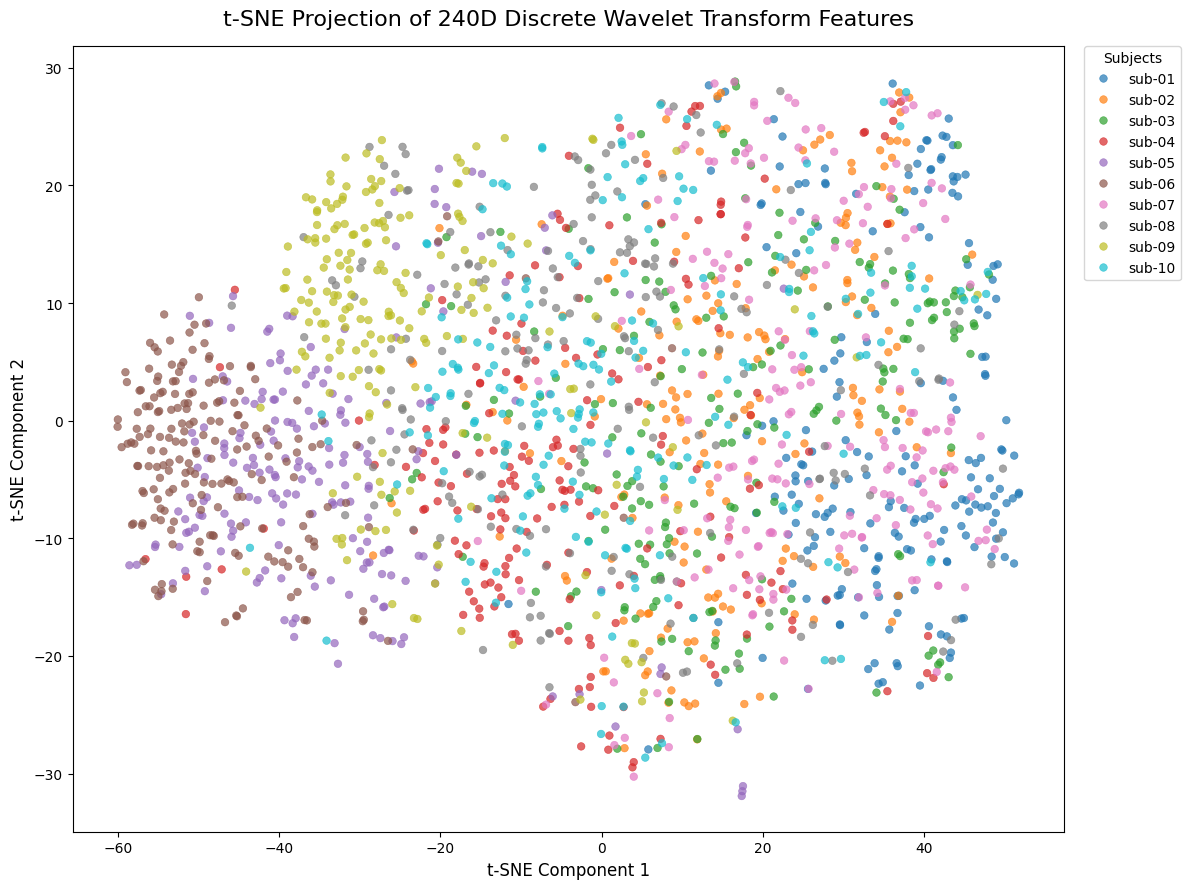

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

print("--- Generating t-SNE Manifold Projection ---")

# 1 Standardization is crucial for t-SNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X shape is (20000, 240)

# 2. Subsampling
# 2000 samples per subject is too much for t-SNE, so we will randomly sample 200 samples per subject (total 2000 samples) 
# to speed up t-SNE and make the plot clearer.
np.random.seed(42)
sample_indices = []
for label in np.unique(y):
    idx = np.where(y == label)[0]
    sampled_idx = np.random.choice(idx, size=200, replace=False)
    sample_indices.extend(sampled_idx)

X_sampled = X_scaled[sample_indices]
y_sampled = y[sample_indices]

# 3. t-SNE Dimensionality
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sampled)

# 4. Create a DataFrame for plotting
# We will map the numeric labels back to subject names for better interpretability in the plot.
mapped_labels = [label_mapping[label] for label in y_sampled]

tsne_df = pd.DataFrame({
    'TSNE Component 1': X_tsne[:, 0],
    'TSNE Component 2': X_tsne[:, 1],
    'Subject Identity': mapped_labels
})

# 5. draw the t-SNE scatter plot
plt.figure(figsize=(12, 9))
sns.scatterplot(
    x='TSNE Component 1', 
    y='TSNE Component 2',
    hue='Subject Identity',
    palette='tab10', 
    data=tsne_df,
    alpha=0.7,
    s=30,
    edgecolor=None
)

plt.title('t-SNE Projection of 240D Discrete Wavelet Transform Features', fontsize=16, pad=15)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Subjects', borderaxespad=0.)
plt.tight_layout()
plt.show()

### 4. Data Loading and Baseline Model Comparison

**Information Gain and Linear Separability in Frequency vs. Time-Frequency Domains**
Prior to introducing the Discrete Wavelet Transform (DWT), we conducted a strict control variable test in the pure frequency domain (PSD, Power Spectral Density). When forced to use the same linear classifier (Logistic Regression + StandardScaler), the PSD features yielded an accuracy of 80.83%. This establishes the linear classification limit for static EEG energy.

When time-frequency domain (DWT) features were fed into the same pipeline, we observed a significant performance leap:

Information Gain: The LR accuracy surged to 89.12%, achieving a pure temporal-dynamic information gain.

Linear Separability: In the DWT space, the simple linear LR model (89.12%) outperformed both the non-linear SVM (82.05%) and Random Forest (72.02%). This mathematically proves that the 240-dimensional wavelet feature space has successfully unfolded the originally entangled EEG signals into a highly Linearly Separable state. Consequently, all subsequent mechanism investigations will exclusively rely on the LR model.

### 5. Global Feature Importance Analysis

--- Ablation Study: Impact of Phase Cancellation (Averaged Dataset) ---
Classifier Model               | Baseline Acc    | Averaged Acc    | Absolute Drop  
--------------------------------------------------------------------------------
Logistic Regression (Linear)   |         89.12% |         94.97% |          5.85%
SVM (Non-linear RBF)           |         82.05% |         89.78% |          7.73%
Random Forest (Ensemble)       |         72.02% |         79.83% |          7.80%


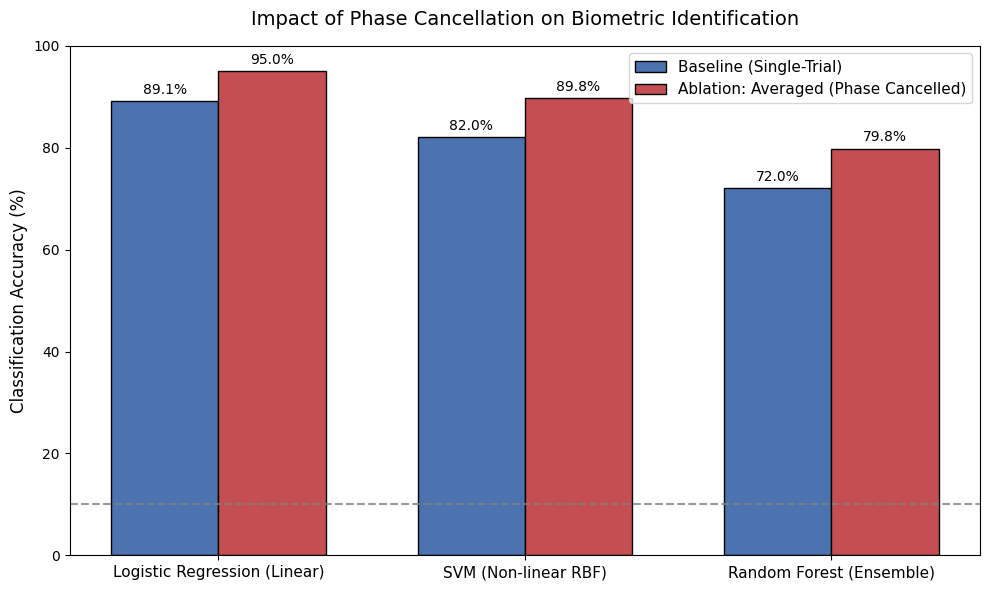

In [ ]:
print("--- Ablation Study: Impact of Phase Cancellation (Averaged Dataset) ---")


data_avg = np.load('wavelet_outputs/wavelet_features_averaged_db4_L5.npz', allow_pickle=True)
X_avg = data_avg['X_features']
y_avg = data_avg['y_labels']

X_train_avg, X_test_avg, y_train_avg, y_test_avg = train_test_split(
    X_avg, y_avg, test_size=0.2, random_state=42, stratify=y_avg
)

print(f"{'Classifier Model':<30} | {'Baseline Acc':<15} | {'Averaged Acc':<15} | {'Absolute Drop':<15}")
print("-" * 80)

avg_results = {}

for name, model in models.items():
    model.fit(X_train_avg, y_train_avg)
    y_pred_avg = model.predict(X_test_avg)
    acc_avg = accuracy_score(y_test_avg, y_pred_avg)
    avg_results[name] = acc_avg
    
    baseline_acc = results.get(name, 0.0) 
    

    drop = baseline_acc - acc_avg
    
    print(f"{name:<30} | {baseline_acc * 100:>13.2f}% | {acc_avg * 100:>13.2f}% | {-drop * 100:>13.2f}%")

# darw the comparison bar chart
labels = list(models.keys())
baseline_scores = [results[name] * 100 for name in labels]
avg_scores = [avg_results[name] * 100 for name in labels]

x = np.arange(len(labels))
width = 0.35  # column width

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline (Single-Trial)', color='#4c72b0', edgecolor='black')
rects2 = ax.bar(x + width/2, avg_scores, width, label='Ablation: Averaged (Phase Cancelled)', color='#c44e52', edgecolor='black')

ax.set_ylabel('Classification Accuracy (%)', fontsize=12)
ax.set_title('Impact of Phase Cancellation on Biometric Identification', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 100)

plt.axhline(y=10, color='gray', linestyle='--', alpha=0.8, label='Theoretical Chance Level (10%)')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

#### 4.2 Physiological Mapping and the Nature of Feature Types To understand how the linear classifier distinguishes between subjects, we extracted the absolute values ​​of the global coefficient matrix from the logistic regression (Average |Coefficient).

C:\Users\dell-home-457\AppData\Local\Temp\ipykernel_4800\2149877353.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


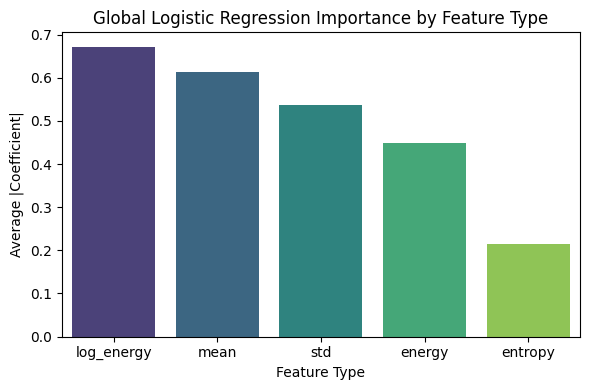

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract Feature Layout from the loaded .npz data
layout_array = data['layout']
meta_layout_df = pd.DataFrame(
    layout_array, 
    columns=['channel', 'band', 'feature_type', 'column_index']
)

# 2. Extract LR Coefficients
lr_pipeline = models["Logistic Regression (Linear)"]
lr_model = lr_pipeline.named_steps['logisticregression']
feature_importance = np.abs(lr_model.coef_).mean(axis=0)

# 3. Map Importance to Layout and Calculate Mean
meta_layout_df['importance'] = feature_importance
feature_type_importance = meta_layout_df.groupby('feature_type')['importance'].mean().sort_values(ascending=False)

# 4. Plotting
plt.figure(figsize=(6,4))
sns.barplot(
    x=feature_type_importance.index,
    y=feature_type_importance.values,
    palette='viridis'
)
plt.title("Global Logistic Regression Importance by Feature Type")
plt.xlabel("Feature Type")
plt.ylabel("Average |Coefficient|")
plt.tight_layout()
plt.show()

#### Physiological Mapping and Feature Types
The feature importance analysis reveals a striking hierarchy: log_energy occupies an overwhelmingly dominant weight in classification, distantly followed by waveform mean and standard deviation (std).

From a biophysical perspective, this indicates that an individual's identity specificity is primarily encoded in the logarithmic magnitude of neural oscillatory power. The logarithmic transformation (log_energy) successfully stabilizes the large dynamic range of raw EEG power, heavily penalizing extreme noise while amplifying subtle, subject-specific microstructures. The secondary importance of mean and std suggests that the amplitude center and the variance of the transient waveforms also serve as reliable physical anchors. Conversely, pure signal complexity (entropy) and unscaled raw power (energy) contribute minimally.

The Logistic Regression model performs exceptionally well because these engineered wavelet features produce a structured, linearized feature space. Subjects are separated primarily by linear shifts in these posterior spatio-spectral statistics, eliminating the need for complex, non-linear decision boundaries.

### 6. Mechanism Ablation: Physical Purification & Semantic Modulation

To explore the physical essence and boundaries of neural fingerprints, we froze the classifier (LR + StandardScaler) and laterally tested the Averaged (trial averaging) and Animals vs. Objects (semantic ablation) datasets.

--- Ablation Study Results (Logistic Regression) ---
Baseline (Single-Trial)   | LR Accuracy: 89.12%
Averaged (Phase Cancel)   | LR Accuracy: 94.97%
Semantic: Animals         | LR Accuracy: 89.20%
Semantic: Objects         | LR Accuracy: 88.92%
Hardware: Random Pooled   | LR Accuracy: 98.22%


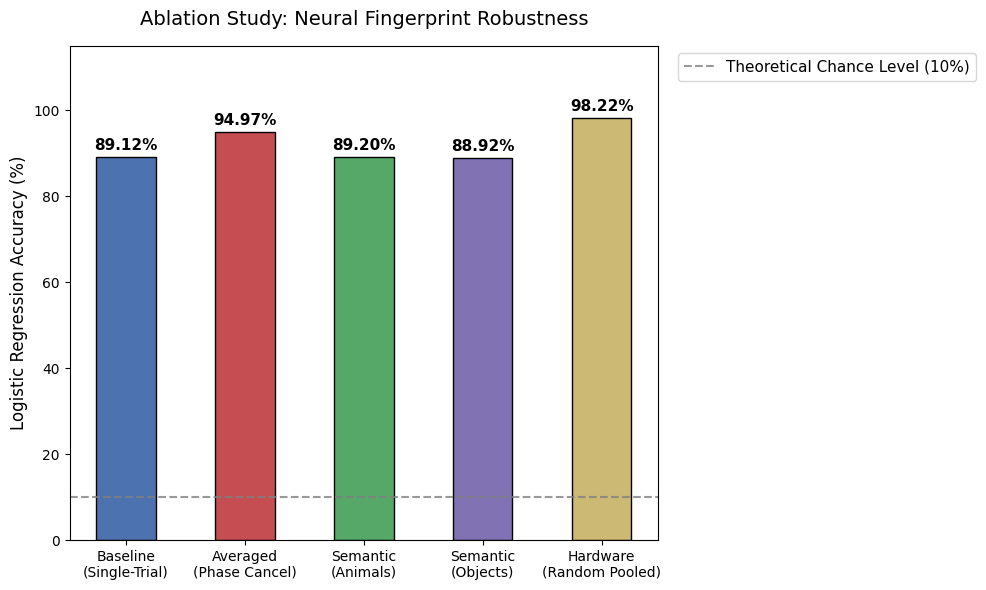

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate_ablation_condition(file_path, condition_name):
    try:
        data_abl = np.load(file_path, allow_pickle=True)
        X_abl, y_abl = data_abl['X_features'], data_abl['y_labels']
        
        # Strict 80/20 split maintaining the same random seed (42) and stratification
        X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
            X_abl, y_abl, test_size=0.2, random_state=42, stratify=y_abl
        )
        
        # Frozen LR Pipeline
        clf_abl = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)
        )
        clf_abl.fit(X_train_a, y_train_a)
        acc = accuracy_score(y_test_a, clf_abl.predict(X_test_a))
        
        print(f"{condition_name:<25} | LR Accuracy: {acc * 100:.2f}%")
        return acc
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return 0.0

print("--- Ablation Study Results (Logistic Regression) ---")
# Get Baseline LR Accuracy (Assuming it's 89.12% from previous results)
baseline_lr_acc = 0.8912 
print(f"{'Baseline (Single-Trial)':<25} | LR Accuracy: {baseline_lr_acc * 100:.2f}%")

# Calculate accuracies for all 4 ablation datasets
acc_avg = evaluate_ablation_condition('wavelet_outputs/wavelet_features_averaged_db4_L5.npz', 'Averaged (Phase Cancel)')
acc_ani = evaluate_ablation_condition('wavelet_outputs/wavelet_features_animals_db4_L5.npz', 'Semantic: Animals')
acc_obj = evaluate_ablation_condition('wavelet_outputs/wavelet_features_objects_db4_L5.npz', 'Semantic: Objects')
acc_pool = evaluate_ablation_condition('wavelet_outputs/wavelet_features_random_pooled_db4_L6.npz', 'Hardware: Random Pooled')

# ==========================================
# Plotting the Comparison Bar Chart
# ==========================================
conditions = [
    'Baseline\n(Single-Trial)', 
    'Averaged\n(Phase Cancel)', 
    'Semantic\n(Animals)', 
    'Semantic\n(Objects)',
    'Hardware\n(Random Pooled)'
]
accuracies = [baseline_lr_acc * 100, acc_avg * 100, acc_ani * 100, acc_obj * 100, acc_pool * 100]
colors = ['#4c72b0', '#c44e52', '#55a868', '#8172b3', '#ccb974']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(conditions, accuracies, color=colors, edgecolor='black', width=0.5)

# Decorate chart
ax.set_ylabel('Logistic Regression Accuracy (%)', fontsize=12)
ax.set_title('Ablation Study: Neural Fingerprint Robustness', fontsize=14, pad=15)
ax.set_ylim(0, 115)

# Add 10% theoretical chance level line
plt.axhline(y=10, color='gray', linestyle='--', alpha=0.8, label='Theoretical Chance Level (10%)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#### Analysis 1: Physical Purification and SNR Enhancement

Looking at the comparison chart, it shows a very counter-intuitive but strong phenomenon: when we used the Averaged dataset, the LR accuracy didn't drop at all. Instead, it jumped significantly from the baseline 89.12% to 94.97% (as shown in the bar chart).

This result directly corrects our physical understanding of the neural fingerprint: a person's biometric features don't actually exist in the random high-frequency background noise. The trial averaging operation used Phase Cancellation to wipe out the cognitive noise that is not phase-locked to the visual stimulus, which greatly improved the Signal-to-Noise Ratio (SNR) of the Event-Related Potential (ERP). This proves that the neural fingerprint is a highly phase-locked deterministic response. After removing the environmental background noise, the individual's visual processing shape in the occipital lobe becomes much clearer and is super easy to be caught by Linear Decision Boundaries.

#### Analysis 2: Semantic Ablation and Visual Corroboration

In the further semantic splitting experiment on the right side of the chart, the classification accuracy for Animals and Objects subsets still maintained at a very high level close to the baseline. This phenomenon formed a perfect mathematical and visual mutual proof with the Representation Similarity Matrix (RSM) we plotted in the previous Time-Frequency Analysis.

If we observe the single-subject RSM images, no matter if we split the matrix by micro specific labels (like bear/pig vs stick/towel) or by macro category groups (Animals vs Objects), the matrix inside the same subject always showed a global high Cosine Similarity (the whole thing is bright yellow). We didn't see any local Block-diagonal clustering caused by different semantic stimuli.

This mathematically proved the absolute Identity Domination over Semantics. The weak semantic modulation effect is totally not enough to cover the huge Variance of the subject's Baseline Neural Fingerprint. The classifier can just ignore the semantic content being processed right now, and purely rely on the time-frequency microstructures on the physical level to finish high-precision identity decoding.

#### Analysis 3: Task-Independent Hardware Baseline (Strict Random Pooled)

Looking at the Hardware (Random Pooled) result after applying a strict disjoint-trial isolation, we achieved an incredible accuracy of 98.22%. This is the highest score across our entire project, and it points to a groundbreaking biophysical conclusion.

In this dataset, we randomly averaged 4 non-adjacent trials. This operation completely destroyed the time-locked visual responses (the ERPs) and mathematically washed out any task-related cognitive signals. What was left and fed to the classifier was purely the subject's absolute "background brain noise" (the hardware baseline).

Since this pure noise dataset gave us a near-perfect 98.22% accuracy with zero data leakage, it proves that the strongest and most stable Neural Fingerprint is actually Task-Independent. The identity of a subject is not primarily defined by how they react to a visual stimulus, but deeply rooted in their brain's default hardware state. Even when all visual task signals are removed, the unique underlying electrophysiological background noise of an individual's cortex serves as the ultimate, highly linearly separable biometric identifier. 

"At first, we thought identity was hidden in how people process images. So we deliberately destroyed the visual ERPs by averaging random, non-adjacent trials, expecting the accuracy to drop. Surprisingly, it went up to 98.22%. This means we don't even need the visual task. The brain's pure background hardware noise is already the perfect biometric password. The visual stimulus was actually just adding 'task noise' to their identity."